# 하울링 예측 AI 데모
학습된 모델로 오디오 신호의 위험도를 예측합니다.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from model import FeedbackClassifier

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Nanum Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 모델 로드
model = FeedbackClassifier(input_size=516)
model.load_state_dict(torch.load('feedback_model.pth'))
model.eval()
print('모델 로드 완료')

모델 로드 완료


In [2]:
SAMPLE_RATE = 44100
DURATION = 1.0
SEGMENT_LENGTH = 1024
LABELS = ['안전', '주의', '위험']
COLORS = ['green', 'orange', 'red']

def pink_noise(n):
    f = np.fft.rfftfreq(n)
    f[0] = 1
    power = 1 / np.sqrt(f)
    power[0] = 0
    phase = np.random.uniform(0, 2 * np.pi, len(f))
    spectrum = power * np.exp(1j * phase)
    return np.fft.irfft(spectrum, n)

def simulate_feedback(gain):
    n_samples = int(SAMPLE_RATE * DURATION)
    distance = np.random.uniform(5, 20)
    delay_samples = int((distance / 343.0) * SAMPLE_RATE)
    output = np.zeros(n_samples)
    t = np.linspace(0, DURATION, n_samples)
    n_freqs = np.random.randint(3, 10)
    freqs = np.random.choice([80,120,180,250,350,500,700,1000,1500,2000,3000,4000,6000,8000], n_freqs, replace=False)
    amplitudes = np.random.uniform(0.1, 1.0, n_freqs)
    input_signal = sum(a * np.sin(2 * np.pi * f * t) for f, a in zip(freqs, amplitudes))
    envelope = np.random.uniform(0.2, 1.0, 20)
    envelope = np.interp(np.linspace(0, 19, n_samples), np.arange(20), envelope)
    input_signal *= envelope
    input_signal += pink_noise(n_samples) * np.random.uniform(0.05, 0.3)
    input_signal *= 0.01
    for i in range(n_samples):
        feedback = output[i - delay_samples] * gain if i >= delay_samples else 0
        output[i] = np.clip(input_signal[i] + feedback, -10, 10)
    return output

def extract_features(segment):
    fft = np.abs(np.fft.rfft(segment))
    max_val = np.max(fft)
    if max_val > 0:
        fft = fft / max_val
    half = len(segment) // 2
    e1 = np.mean(segment[:half] ** 2)
    e2 = np.mean(segment[half:] ** 2)
    energy_ratio = e2 / e1 if e1 > 0 else 1.0
    peak = np.max(np.abs(segment))
    zcr = np.mean(np.abs(np.diff(np.sign(segment)))) / 2
    return np.concatenate([fft, [energy_ratio, peak, zcr]])

def predict(signal):
    results = []
    for start in range(0, len(signal) - SEGMENT_LENGTH, SEGMENT_LENGTH):
        segment = signal[start:start + SEGMENT_LENGTH]
        features = extract_features(segment)
        x = torch.FloatTensor(features).unsqueeze(0)
        with torch.no_grad():
            out = model(x)
            pred = torch.argmax(out).item()
        results.append(pred)
    return results

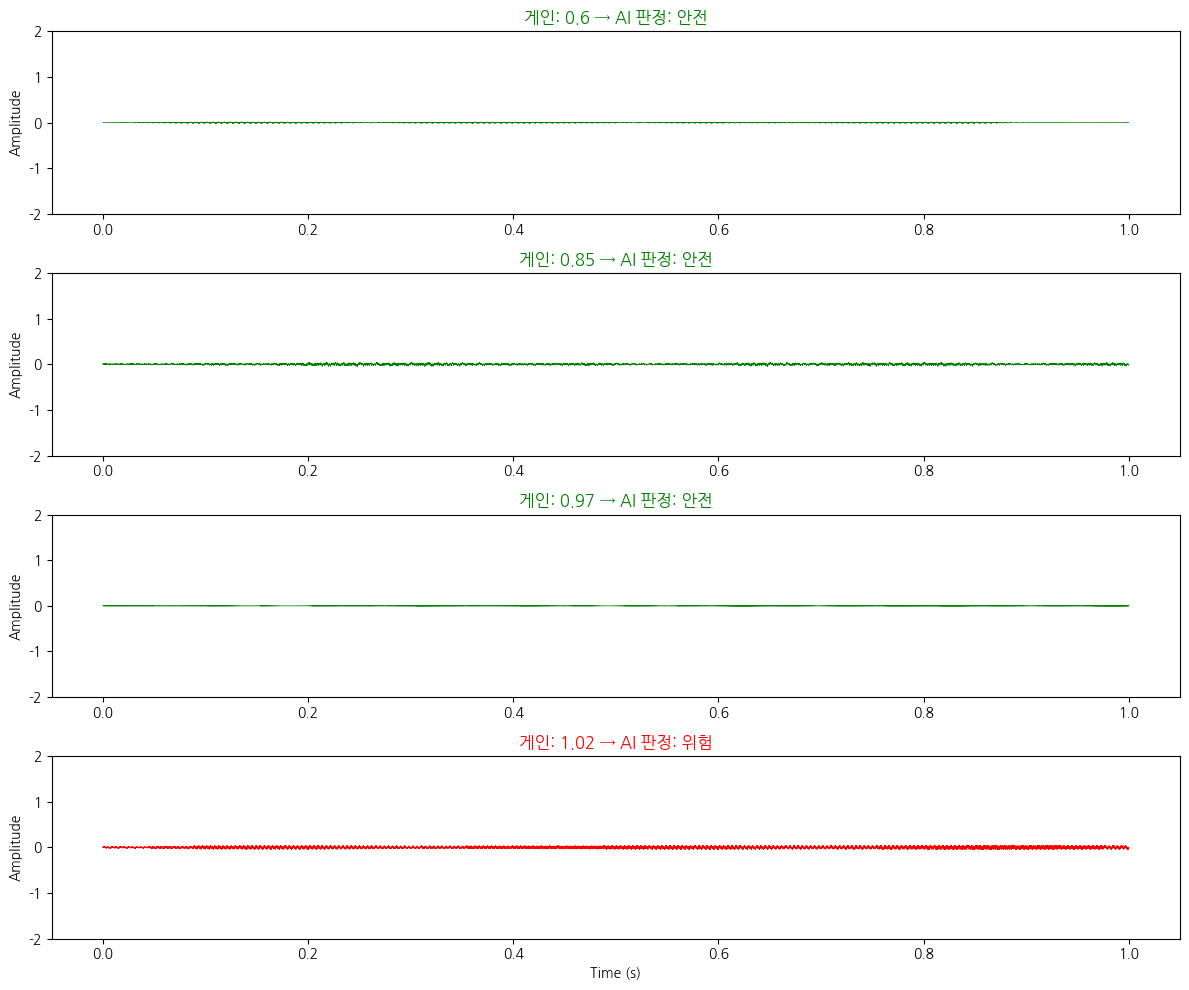

결과 저장 완료: demo_result.png


In [3]:
# 게인별 예측 결과 시각화
test_gains = [0.6, 0.85, 0.97, 1.02]

fig, axes = plt.subplots(len(test_gains), 1, figsize=(12, 10))

for idx, gain in enumerate(test_gains):
    signal = simulate_feedback(gain)
    preds = predict(signal)
    most_common = max(set(preds), key=preds.count)
    label = LABELS[most_common]
    color = COLORS[most_common]

    time = np.linspace(0, DURATION, len(signal))
    axes[idx].plot(time, signal, linewidth=0.5, color=color)
    axes[idx].set_title(f'게인: {gain} → AI 판정: {label}', color=color, fontsize=12)
    axes[idx].set_ylabel('Amplitude')
    axes[idx].set_ylim(-2, 2)

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig('demo_result.png', dpi=150)
plt.show()
print('결과 저장 완료: demo_result.png')

게인 0.50 → 위험도 점수: 2.00 (위험)
게인 0.55 → 위험도 점수: 1.19 (주의)
게인 0.60 → 위험도 점수: 2.00 (위험)
게인 0.65 → 위험도 점수: 1.26 (주의)
게인 0.70 → 위험도 점수: 0.95 (주의)
게인 0.75 → 위험도 점수: 0.00 (안전)
게인 0.80 → 위험도 점수: 1.84 (위험)
게인 0.85 → 위험도 점수: 1.49 (주의)
게인 0.90 → 위험도 점수: 1.74 (위험)
게인 0.95 → 위험도 점수: 1.49 (주의)
게인 1.00 → 위험도 점수: 1.28 (주의)
게인 1.05 → 위험도 점수: 1.23 (주의)


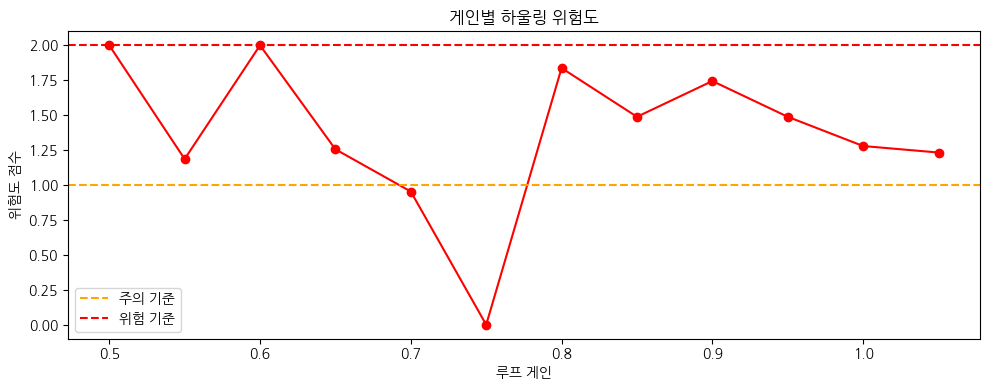

In [4]:
# 실시간 위험도 스캔 — 게인 0.5~1.05 전체
gains = np.arange(0.5, 1.06, 0.05)
danger_scores = []

for gain in gains:
    signal = simulate_feedback(gain)
    preds = predict(signal)
    score = np.mean(preds)  # 0=안전, 1=주의, 2=위험 평균
    danger_scores.append(score)
    print(f'게인 {gain:.2f} → 위험도 점수: {score:.2f} ({LABELS[round(score)]})')

plt.figure(figsize=(10, 4))
plt.plot(gains, danger_scores, marker='o', color='red')
plt.axhline(y=1, color='orange', linestyle='--', label='주의 기준')
plt.axhline(y=2, color='red', linestyle='--', label='위험 기준')
plt.xlabel('루프 게인')
plt.ylabel('위험도 점수')
plt.title('게인별 하울링 위험도')
plt.legend()
plt.tight_layout()
plt.savefig('danger_score.png', dpi=150)
plt.show()